# Train a Deep Learning model with the timeseries data


In [1]:
import numpy as np
import pandas as pd
from sklearn.model_selection import GroupShuffleSplit, StratifiedShuffleSplit
from sklearn.utils.class_weight import compute_class_weight
from tensorflow import keras
import json

from core.matlab_data_loader import MatlabDataLoader

from pathlib import Path

import core.constants as c

RANDOM_STATE = 42
RANDOM_STATE_2 = 6
np.random.seed(RANDOM_STATE)
MODEL_NAME = "Baseline-v1"

In [2]:
RESULTS_DIR = Path(c.RICKD_PROCESSED_DATA_FOLDER) / 'timeseries'

all_sessions_matrix = np.load(RESULTS_DIR / 'timeseries_matrix.npy')
with open(RESULTS_DIR / 'timeseries_channels.json', 'r') as f:
    channels = json.load(f)
with open(RESULTS_DIR / 'timeseries_sessions.json', 'r') as f:
    valid_session_ids = json.load(f)

print("Shape of the timeseries matrix: ", all_sessions_matrix.shape)
print("Number of channels: ", len(channels))
print("Number of sessions: ", len(valid_session_ids))

for channel in channels:
    print(channel)

Shape of the timeseries matrix:  (1813, 101, 48)
Number of channels:  48
Number of sessions:  1813
L_ankle_angle_X
L_ankle_angle_Y
L_ankle_angle_Z
L_ankle_velocity_X
L_ankle_velocity_Y
L_ankle_velocity_Z
L_foot_angle_X
L_foot_angle_Y
L_foot_angle_Z
L_foot_velocity_X
L_foot_velocity_Y
L_foot_velocity_Z
L_hip_angle_X
L_hip_angle_Y
L_hip_angle_Z
L_hip_velocity_X
L_hip_velocity_Y
L_hip_velocity_Z
L_knee_angle_X
L_knee_angle_Y
L_knee_angle_Z
L_knee_velocity_X
L_knee_velocity_Y
L_knee_velocity_Z
R_ankle_angle_X
R_ankle_angle_Y
R_ankle_angle_Z
R_ankle_velocity_X
R_ankle_velocity_Y
R_ankle_velocity_Z
R_foot_angle_X
R_foot_angle_Y
R_foot_angle_Z
R_foot_velocity_X
R_foot_velocity_Y
R_foot_velocity_Z
R_hip_angle_X
R_hip_angle_Y
R_hip_angle_Z
R_hip_velocity_X
R_hip_velocity_Y
R_hip_velocity_Z
R_knee_angle_X
R_knee_angle_Y
R_knee_angle_Z
R_knee_velocity_X
R_knee_velocity_Y
R_knee_velocity_Z


In [3]:
loader = MatlabDataLoader()

session_data = loader.get_session_data_full_cleaned().set_index("id")
metadata_columns = ["age", "Height", "Weight", "Gender", "DominantLeg", "speed_r"]
metadata = session_data[metadata_columns]
complete_metadata = metadata.dropna()

num_complete_rows = complete_metadata.shape[0]
print(f"\nNumber of rows with a value for all metadata columns: {num_complete_rows}")
complete_metadata.info(verbose=True)



Number of rows with a value for all metadata columns: 1476
<class 'pandas.core.frame.DataFrame'>
Index: 1476 entries, 100560_20120717T103748 to 201099_20150414T092041
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   age          1476 non-null   float64
 1   Height       1476 non-null   float64
 2   Weight       1476 non-null   float64
 3   Gender       1476 non-null   object 
 4   DominantLeg  1476 non-null   object 
 5   speed_r      1476 non-null   float64
dtypes: float64(4), object(2)
memory usage: 80.7+ KB


In [4]:
# Compare valid_session_ids against sessions with complete metadata
session_ids = set(session_data.index.astype(str))
valid_ids = set(map(str, valid_session_ids))
intersection_ids = valid_ids & session_ids
complete_ids = set(complete_metadata.index.astype(str))
complete_intersection_ids = complete_ids & valid_ids

print(f"Number of sessions: {len(session_ids)}")
print(f"Number of time-series sessions: {len(valid_ids)}")
print(f"Number of sessions with complete metadata: {len(complete_ids)}")
print(f"Number of sessions present both in metadata and time-series: {len(intersection_ids)}")
print(f"Number of sessions with complete metadata and present in time-series: {len(complete_intersection_ids)}")
print(f"We loose {(1-(len(complete_intersection_ids) / len(valid_ids)))*100:.2f}% of the data due to missing metadata.")

Number of sessions: 1832
Number of time-series sessions: 1813
Number of sessions with complete metadata: 1476
Number of sessions present both in metadata and time-series: 1812
Number of sessions with complete metadata and present in time-series: 1456
We loose 19.69% of the data due to missing metadata.


In [5]:
metadata_common = complete_metadata.loc[list(complete_intersection_ids)]
metadata_common

,age,Height,Weight,Gender,DominantLeg,speed_r
id,,,,,,
100269_20110629T204732,28.0,159.2,63.3,female,right,2.686292
100290_20120703T123327,41.0,194.6,90.0,male,left,2.693761
100021_20110404T121612,37.0,176.4,79.6,male,right,2.479600
101091_20140507T130001,39.0,174.0,87.5,male,right,2.508919
100783_20130703T160016,51.0,174.5,62.6,female,right,2.719622
...,...,...,...,...,...,...
200330_20140826T092928,27.0,175.0,57.0,female,right,3.013791
200370_20141017T073247,27.0,160.0,46.0,female,right,3.687389
200367_20141013T140547,60.0,171.0,83.0,female,right,2.731546


In [6]:
filtered_indices = [i for i, sid in enumerate(valid_session_ids) if sid in complete_intersection_ids]
sessions_matrix_common = all_sessions_matrix[filtered_indices]
sessions_matrix_common.shape
type(sessions_matrix_common)

numpy.ndarray

In [7]:
is_injured_common = session_data.loc[list(complete_intersection_ids), 'is_injured']
is_injured_common

id
100269_20110629T204732    False
100290_20120703T123327     True
100021_20110404T121612     True
101091_20140507T130001     True
100783_20130703T160016    False
                          ...  
200330_20140826T092928     True
200370_20141017T073247     True
200367_20141013T140547     True
100076_20110602T115410     True
200274_20140522T152910     True
Name: is_injured, Length: 1456, dtype: bool

In [8]:
subject_id_common = session_data.loc[list(complete_intersection_ids), 'sub_id']
subject_id_common

id
100269_20110629T204732    100269
100290_20120703T123327    100290
100021_20110404T121612    100021
101091_20140507T130001    101091
100783_20130703T160016    100783
                           ...  
200330_20140826T092928    200330
200370_20141017T073247    200370
200367_20141013T140547    200367
100076_20110602T115410    100076
200274_20140522T152910    200274
Name: sub_id, Length: 1456, dtype: int64

In [9]:
# Class imbalance:
is_injured_common.value_counts(normalize=True)

is_injured
True     0.727335
False    0.272665
Name: proportion, dtype: float64

In [10]:
# N = 1456 -- Sessions with complete metadata and present in time-series.
X_ts: np.ndarray = sessions_matrix_common  #  (N, 101, 54)
X_meta: pd.DataFrame = metadata_common  # (N, 6)
y: pd.Series = is_injured_common  # (N,)
subject_id: pd.Series = subject_id_common  # (N,)

In [11]:
# Handle metadata preprocessing (one-hot encoding for categorical variables)
import pandas as pd

print("=== METADATA PREPROCESSING ===")
print("Original metadata columns:", X_meta.columns.tolist())
print("Original metadata shape:", X_meta.shape)

# One-hot encode categorical variables
X_meta_encoded = pd.get_dummies(X_meta, columns=['Gender', 'DominantLeg'], drop_first=False)
print("After one-hot encoding:", X_meta_encoded.columns.tolist())
print("New metadata shape:", X_meta_encoded.shape)

# Update the values array
X_meta_values = X_meta_encoded.values.astype(np.float32)
meta_feature_names = X_meta_encoded.columns.tolist()

print(f"Final metadata shape: {X_meta_values.shape}")
print(f"Feature names: {meta_feature_names}")


=== METADATA PREPROCESSING ===
Original metadata columns: ['age', 'Height', 'Weight', 'Gender', 'DominantLeg', 'speed_r']
Original metadata shape: (1456, 6)
After one-hot encoding: ['age', 'Height', 'Weight', 'speed_r', 'Gender_female', 'Gender_male', 'DominantLeg_ambidextrous', 'DominantLeg_left', 'DominantLeg_right']
New metadata shape: (1456, 9)
Final metadata shape: (1456, 9)
Feature names: ['age', 'Height', 'Weight', 'speed_r', 'Gender_female', 'Gender_male', 'DominantLeg_ambidextrous', 'DominantLeg_left', 'DominantLeg_right']


In [12]:
# Step 1: Data Exploration and Preprocessing
print("=== DATA OVERVIEW ===")
print(f"Timeseries shape: {X_ts.shape}")  # (N, 101, 48)
print(f"Metadata shape: {X_meta_values.shape}")  # (N, metadata_features)
print(f"Labels shape: {y.shape}")        # (N,)
print(f"Subject IDs shape: {subject_id.shape}")  # (N,)

# Check class distribution
unique, counts = np.unique(y, return_counts=True)
print(f"\nClass distribution:")
for label, count in zip(unique, counts):
    print(f"  Class {int(label)}: {count} samples ({count/len(y)*100:.1f}%)")

# Check for any missing values
print(f"\nMissing values in timeseries: {np.isnan(X_ts).sum()}")
print(f"Missing values in metadata: {np.isnan(X_meta_values).sum()}")

# Basic statistics
print(f"\nTimeseries stats:")
print(f"  Min: {X_ts.min():.3f}, Max: {X_ts.max():.3f}")
print(f"  Mean: {X_ts.mean():.3f}, Std: {X_ts.std():.3f}")

print(f"\nMetadata stats:")
print(f"  Min: {X_meta_values.min():.3f}, Max: {X_meta_values.max():.3f}")
print(f"  Mean: {X_meta_values.mean():.3f}, Std: {X_meta_values.std():.3f}")


=== DATA OVERVIEW ===
Timeseries shape: (1456, 101, 48)
Metadata shape: (1456, 9)
Labels shape: (1456,)
Subject IDs shape: (1456,)

Class distribution:
  Class 0: 397 samples (27.3%)
  Class 1: 1059 samples (72.7%)

Missing values in timeseries: 0
Missing values in metadata: 0

Timeseries stats:
  Min: -11442.526, Max: 6956.552
  Mean: -0.929, Std: 113.039

Metadata stats:
  Min: 0.000, Max: 196.500
  Mean: 31.827, Std: 55.333


In [13]:
# Step 1: Data Exploration and Preprocessing
print("=== DATA OVERVIEW ===")
print(f"Timeseries shape: {X_ts.shape}")  # (N, 101, 48)
print(f"Metadata shape: {X_meta.shape}")  # (N, metadata_features)
print(f"Labels shape: {y.shape}")        # (N,)
print(f"Subject IDs shape: {subject_id.shape}")  # (N,)

# Check class distribution
unique, counts = np.unique(y, return_counts=True)
print(f"\nClass distribution:")
for label, count in zip(unique, counts):
    print(f"  Class {int(label)}: {count} samples ({count/len(y)*100:.1f}%)")

# Check for any missing values
print(f"\nMissing values in timeseries: {np.isnan(X_ts).sum()}")
print(f"Missing values in metadata: {X_meta.isna().any(axis=1).sum()}")


=== DATA OVERVIEW ===
Timeseries shape: (1456, 101, 48)
Metadata shape: (1456, 6)
Labels shape: (1456,)
Subject IDs shape: (1456,)

Class distribution:
  Class 0: 397 samples (27.3%)
  Class 1: 1059 samples (72.7%)

Missing values in timeseries: 0
Missing values in metadata: 0


In [14]:
# Step 2: Data Preprocessing

# Normalize timeseries data (per feature across all samples)
from sklearn.preprocessing import StandardScaler

# Reshape for scaling: (N*101, 48) -> scale -> reshape back to (N, 101, 48)
N, T, C = X_ts.shape
X_ts_reshaped = X_ts.reshape(-1, C)
scaler_ts = StandardScaler()
X_ts_scaled = scaler_ts.fit_transform(X_ts_reshaped).reshape(N, T, C).astype(np.float32)

# Normalize metadata
scaler_meta = StandardScaler()
X_meta_scaled = scaler_meta.fit_transform(X_meta_values).astype(np.float32)

print("=== AFTER PREPROCESSING ===")
print(f"Timeseries scaled stats:")
print(f"  Min: {X_ts_scaled.min():.3f}, Max: {X_ts_scaled.max():.3f}")
print(f"  Mean: {X_ts_scaled.mean():.3f}, Std: {X_ts_scaled.std():.3f}")

print(f"\nMetadata scaled stats:")
print(f"  Min: {X_meta_scaled.min():.3f}, Max: {X_meta_scaled.max():.3f}")
print(f"  Mean: {X_meta_scaled.mean():.3f}, Std: {X_meta_scaled.std():.3f}")


=== AFTER PREPROCESSING ===
Timeseries scaled stats:
  Min: -99.506, Max: 67.621
  Mean: -0.000, Std: 1.000

Metadata scaled stats:
  Min: -5.607, Max: 38.144
  Mean: 0.000, Std: 1.000


In [15]:
# Step 3: Train-Test Split with Subject-level Splitting
# Important: Ensure no subject appears in both train and test sets

unique_subjects = np.unique(subject_id)
print(f"Total unique subjects: {len(unique_subjects)}")

# Use GroupShuffleSplit to ensure subject-level separation
splitter = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=RANDOM_STATE)
train_idx, test_idx = next(splitter.split(X_ts_scaled, y, groups=subject_id))

# Split the data
X_ts_train, X_ts_test = X_ts_scaled[train_idx], X_ts_scaled[test_idx]
X_meta_train, X_meta_test = X_meta_scaled[train_idx], X_meta_scaled[test_idx]
y_train, y_test = y[train_idx], y[test_idx]
subject_train, subject_test = subject_id[train_idx], subject_id[test_idx]

print(f"\n=== TRAIN-TEST SPLIT ===")
print(f"Training set: {len(train_idx)} sessions from {len(np.unique(subject_train))} subjects")
print(f"Test set: {len(test_idx)} sessions from {len(np.unique(subject_test))} subjects")

# Verify no subject overlap
subject_overlap = set(subject_train) & set(subject_test)
print(f"Subject overlap: {len(subject_overlap)} (should be 0)")

# Check class distribution in splits
train_counts = np.bincount(y_train.astype(int))
test_counts = np.bincount(y_test.astype(int))
print(f"\nTrain class distribution: {train_counts} ({train_counts/len(y_train)*100}%)")
print(f"Test class distribution: {test_counts} ({test_counts/len(y_test)*100}%)")


Total unique subjects: 1185

=== TRAIN-TEST SPLIT ===
Training set: 1168 sessions from 948 subjects
Test set: 288 sessions from 237 subjects
Subject overlap: 0 (should be 0)

Train class distribution: [323 845] ([27.65410959 72.34589041]%)
Test class distribution: [ 74 214] ([25.69444444 74.30555556]%)


/var/folders/2w/vl1bz9zs2c37dzy7d38b9cbm0000gn/T/ipykernel_43906/56564008.py:14: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  y_train, y_test = y[train_idx], y[test_idx]
/var/folders/2w/vl1bz9zs2c37dzy7d38b9cbm0000gn/T/ipykernel_43906/56564008.py:15: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  subject_train, subject_test = subject_id[train_idx], subject_id[test_idx]


In [16]:
# Step 4: Handle Class Imbalance
# Calculate class weights to handle the 70-30 imbalance

class_weights = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
class_weight_dict = {i: weight for i, weight in enumerate(class_weights)}

print(f"=== CLASS WEIGHTS ===")
print(f"Class weights: {class_weight_dict}")
print(f"This will penalize misclassifying the minority class more heavily")


=== CLASS WEIGHTS ===
Class weights: {0: np.float64(1.8080495356037152), 1: np.float64(0.6911242603550296)}
This will penalize misclassifying the minority class more heavily


In [17]:
# Step 5: Build the Deep Learning Model
# Hybrid architecture: CNN+LSTM for timeseries + Dense layers for metadata

import tensorflow as tf
from tensorflow.keras import layers, Model, Input
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint


def create_simple_baseline_model(ts_shape, meta_shape):
    """Simple baseline to verify data pipeline works"""
    
    # Timeseries branch - simplified
    ts_input = Input(shape=ts_shape, name='timeseries_input')
    x = layers.GlobalAveragePooling1D()(ts_input)  # Simple pooling
    ts_features = layers.Dense(32, activation='relu')(x)
    
    # Metadata branch
    meta_input = Input(shape=(meta_shape,), name='metadata_input')
    meta_features = layers.Dense(16, activation='relu')(meta_input)
    
    # Combine and classify
    combined = layers.Concatenate()([ts_features, meta_features])
    x = layers.Dense(32, activation='relu')(combined)
    output = layers.Dense(1, activation='sigmoid')(x)
    
    return Model(inputs=[ts_input, meta_input], outputs=output)


# Create the model
model = create_simple_baseline_model(
    ts_shape=(X_ts_train.shape[1], X_ts_train.shape[2]),  # (101, 48)
    meta_shape=X_meta_train.shape[1]  # metadata features
)

model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ timeseries_input    │ (None, 101, 48)   │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 48)        │          0 │ timeseries_input… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ metadata_input      │ (None, 9)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 32)        │      1,568 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 16)        │        160 │ metadata_input[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 48)        │          0 │ dense[0][0],      │
│ (Concatenate)       │                   │            │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 32)        │      1,568 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 1)         │         33 │ dense_2[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 3,329 (13.00 KB)

 Trainable params: 3,329 (13.00 KB)

 Non-trainable params: 0 (0.00 B)

In [18]:
# Step 6: Compile the Model
model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy', 'precision', 'recall']
)

print("Model compiled successfully!")


Model compiled successfully!


In [19]:
# Step 7: Set up Training Callbacks
from pathlib import Path

# Create results directory
RESULTS_DIR = Path(c.RICKD_PROCESSED_DATA_FOLDER).parent / 'results' / 'models' / 'deep_learning'
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

# Define callbacks
callbacks = [
    # Early stopping to prevent overfitting
    EarlyStopping(
        monitor='val_loss',
        patience=15,
        restore_best_weights=True,
        verbose=1
    ),
    
    # Reduce learning rate when loss plateaus
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=8,
        min_lr=1e-7,
        verbose=1
    ),
    
    # Save best model
    ModelCheckpoint(
        filepath=str(RESULTS_DIR / f'best_{MODEL_NAME}_model.h5'),
        monitor='val_loss',
        save_best_only=True,
        verbose=1
    )
]

print(f"Callbacks configured. Models will be saved to: {RESULTS_DIR}")


Callbacks configured. Models will be saved to: /Users/adrianzapaterreig/Documents/Personal/TFM/data/Running Injury Clinic Kinematic Dataset/results/models/deep_learning


In [20]:
# Step 8: Create Validation Split
# Further split training data for validation (80% train, 20% val from training set)

val_splitter = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=RANDOM_STATE_2)
train_val_idx, val_idx = next(val_splitter.split(X_ts_train, y_train, groups=subject_train))

# Create validation split
X_ts_train_final = X_ts_train[train_val_idx]
X_meta_train_final = X_meta_train[train_val_idx]
y_train_final = y_train[train_val_idx]

X_ts_val = X_ts_train[val_idx]
X_meta_val = X_meta_train[val_idx]
y_val = y_train[val_idx]

print(f"=== FINAL DATA SPLITS ===")
print(f"Training: {len(X_ts_train_final)} sessions")
print(f"Validation: {len(X_ts_val)} sessions")
print(f"Test: {len(X_ts_test)} sessions")

# Verify no subject overlap between final train and val
subject_train_final = subject_train[train_val_idx]
subject_val = subject_train[val_idx]
overlap = set(subject_train_final) & set(subject_val)
print(f"Train-Val subject overlap: {len(overlap)} (should be 0)")


=== FINAL DATA SPLITS ===
Training: 942 sessions
Validation: 226 sessions
Test: 288 sessions
Train-Val subject overlap: 0 (should be 0)


/var/folders/2w/vl1bz9zs2c37dzy7d38b9cbm0000gn/T/ipykernel_43906/3304217128.py:10: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  y_train_final = y_train[train_val_idx]
/var/folders/2w/vl1bz9zs2c37dzy7d38b9cbm0000gn/T/ipykernel_43906/3304217128.py:14: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  y_val = y_train[val_idx]
/var/folders/2w/vl1bz9zs2c37dzy7d38b9cbm0000gn/T/ipykernel_43906/3304217128.py:22: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `se

In [21]:
# Step 9: Train the Model
print("=== STARTING TRAINING ===")
print("This may take several minutes depending on your hardware...")

# Set random seeds for reproducibility
tf.random.set_seed(RANDOM_STATE)

history = model.fit(
    x=[X_ts_train_final, X_meta_train_final],
    y=y_train_final,
    validation_data=([X_ts_val, X_meta_val], y_val),
    epochs=100,
    batch_size=32,
    class_weight=class_weight_dict,
    callbacks=callbacks,
    verbose=1
)

print("Training completed!")


=== STARTING TRAINING ===
This may take several minutes depending on your hardware...
Epoch 1/100
 1/30 ━━━━━━━━━━━━━━━━━━━━ 12s 438ms/step - accuracy: 0.5625 - loss: 0.7402 - precision: 0.7333 - recall: 0.5238
Epoch 1: val_loss improved from None to 0.72081, saving model to /Users/adrianzapaterreig/Documents/Personal/TFM/data/Running Injury Clinic Kinematic Dataset/results/models/deep_learning/best_Baseline-v1_model.h5


30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.5021 - loss: 0.7095 - precision: 0.7317 - recall: 0.4754 - val_accuracy: 0.4381 - val_loss: 0.7208 - val_precision: 0.7374 - val_recall: 0.4195 - learning_rate: 0.0010
Epoch 2/100
 1/30 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.5312 - loss: 0.6958 - precision: 0.7500 - recall: 0.4286
Epoch 2: val_loss improved from 0.72081 to 0.70954, saving model to /Users/adrianzapaterreig/Documents/Personal/TFM/data/Running Injury Clinic Kinematic Dataset/results/models/deep_learning/best_Baseline-v1_model.h5


30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5414 - loss: 0.6884 - precision: 0.7698 - recall: 0.5082 - val_accuracy: 0.4867 - val_loss: 0.7095 - val_precision: 0.7736 - val_recall: 0.4713 - learning_rate: 0.0010
Epoch 3/100
 1/30 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.5938 - loss: 0.6810 - precision: 0.7857 - recall: 0.5238
Epoch 3: val_loss improved from 0.70954 to 0.70459, saving model to /Users/adrianzapaterreig/Documents/Personal/TFM/data/Running Injury Clinic Kinematic Dataset/results/models/deep_learning/best_Baseline-v1_model.h5


30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.5616 - loss: 0.6765 - precision: 0.7905 - recall: 0.5231 - val_accuracy: 0.4867 - val_loss: 0.7046 - val_precision: 0.7685 - val_recall: 0.4770 - learning_rate: 0.0010
Epoch 4/100
 1/30 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.6562 - loss: 0.6666 - precision: 0.8125 - recall: 0.6190
Epoch 4: val_loss improved from 0.70459 to 0.70039, saving model to /Users/adrianzapaterreig/Documents/Personal/TFM/data/Running Injury Clinic Kinematic Dataset/results/models/deep_learning/best_Baseline-v1_model.h5


30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.5998 - loss: 0.6665 - precision: 0.8141 - recall: 0.5678 - val_accuracy: 0.5044 - val_loss: 0.7004 - val_precision: 0.7672 - val_recall: 0.5115 - learning_rate: 0.0010
Epoch 5/100
 1/30 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7188 - loss: 0.6543 - precision: 0.8333 - recall: 0.7143
Epoch 5: val_loss improved from 0.70039 to 0.69973, saving model to /Users/adrianzapaterreig/Documents/Personal/TFM/data/Running Injury Clinic Kinematic Dataset/results/models/deep_learning/best_Baseline-v1_model.h5


...

30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6444 - loss: 0.6390 - precision: 0.8415 - recall: 0.6170 - val_accuracy: 0.5265 - val_loss: 0.6957 - val_precision: 0.7815 - val_recall: 0.5345 - learning_rate: 0.0010
Epoch 8/100
 1/30 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.7812 - loss: 0.6217 - precision: 0.8889 - recall: 0.7619
Epoch 8: val_loss improved from 0.69572 to 0.69308, saving model to /Users/adrianzapaterreig/Documents/Personal/TFM/data/Running Injury Clinic Kinematic Dataset/results/models/deep_learning/best_Baseline-v1_model.h5


30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6592 - loss: 0.6298 - precision: 0.8500 - recall: 0.6334 - val_accuracy: 0.5354 - val_loss: 0.6931 - val_precision: 0.7851 - val_recall: 0.5460 - learning_rate: 0.0010
Epoch 9/100
 1/30 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.7812 - loss: 0.6107 - precision: 0.8889 - recall: 0.7619
Epoch 9: val_loss improved from 0.69308 to 0.69104, saving model to /Users/adrianzapaterreig/Documents/Personal/TFM/data/Running Injury Clinic Kinematic Dataset/results/models/deep_learning/best_Baseline-v1_model.h5


30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6762 - loss: 0.6205 - precision: 0.8560 - recall: 0.6557 - val_accuracy: 0.5487 - val_loss: 0.6910 - val_precision: 0.7903 - val_recall: 0.5632 - learning_rate: 0.0010
Epoch 10/100
 1/30 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.7812 - loss: 0.6003 - precision: 0.8889 - recall: 0.7619
Epoch 10: val_loss improved from 0.69104 to 0.69028, saving model to /Users/adrianzapaterreig/Documents/Personal/TFM/data/Running Injury Clinic Kinematic Dataset/results/models/deep_learning/best_Baseline-v1_model.h5


30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6879 - loss: 0.6114 - precision: 0.8632 - recall: 0.6677 - val_accuracy: 0.5619 - val_loss: 0.6903 - val_precision: 0.8049 - val_recall: 0.5690 - learning_rate: 0.0010
Epoch 11/100
 1/30 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.7812 - loss: 0.5911 - precision: 0.8889 - recall: 0.7619
Epoch 11: val_loss improved from 0.69028 to 0.68936, saving model to /Users/adrianzapaterreig/Documents/Personal/TFM/data/Running Injury Clinic Kinematic Dataset/results/models/deep_learning/best_Baseline-v1_model.h5


30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6996 - loss: 0.6022 - precision: 0.8702 - recall: 0.6796 - val_accuracy: 0.5619 - val_loss: 0.6894 - val_precision: 0.8049 - val_recall: 0.5690 - learning_rate: 0.0010
Epoch 12/100
 1/30 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.7812 - loss: 0.5811 - precision: 0.8889 - recall: 0.7619
Epoch 12: val_loss did not improve from 0.68936
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7049 - loss: 0.5929 - precision: 0.8729 - recall: 0.6855 - val_accuracy: 0.5575 - val_loss: 0.6900 - val_precision: 0.7984 - val_recall: 0.5690 - learning_rate: 0.0010
Epoch 13/100
 1/30 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7500 - loss: 0.5733 - precision: 0.8824 - recall: 0.7143
Epoch 13: val_loss did not improve from 0.68936
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7134 - loss: 0.5832 - precision: 0.8790 - recall: 0.6930 - val_accuracy: 0.5619 - val_loss: 0.6909 - val_precision: 0.7953 - val_recall: 0.5805 - learning_rate: 0

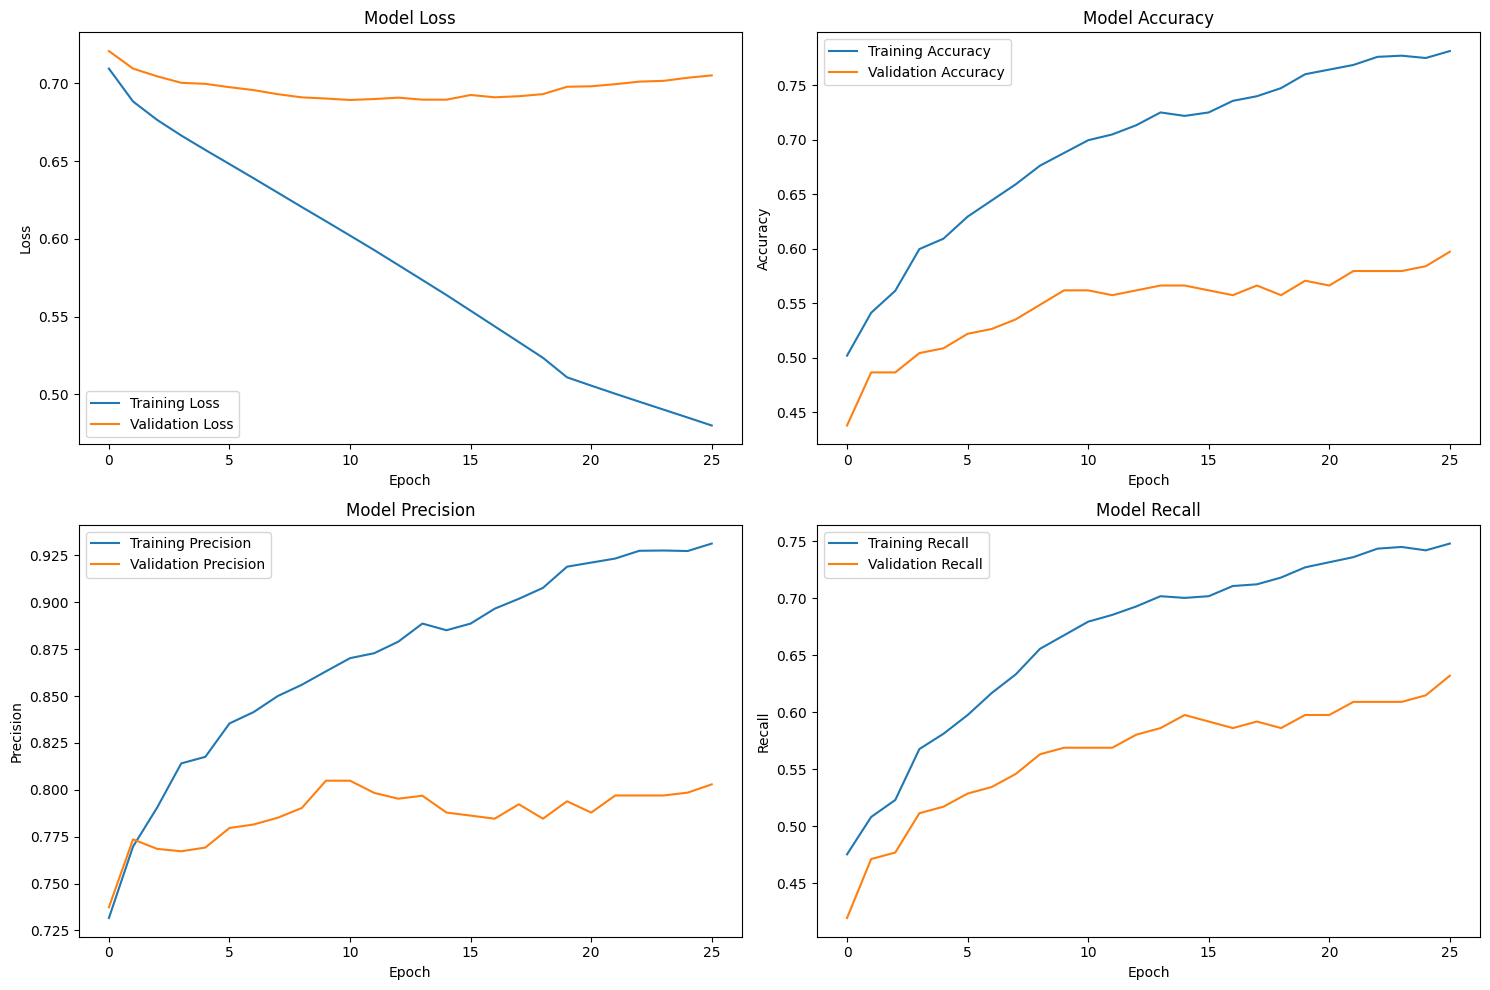

Training history plot saved to: /Users/adrianzapaterreig/Documents/Personal/TFM/data/Running Injury Clinic Kinematic Dataset/results/models/deep_learning/training_history.png


<Figure size 640x480 with 0 Axes>

In [22]:
# Step 10: Plot Training History
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Loss
axes[0, 0].plot(history.history['loss'], label='Training Loss')
axes[0, 0].plot(history.history['val_loss'], label='Validation Loss')
axes[0, 0].set_title('Model Loss')
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Loss')
axes[0, 0].legend()

# Accuracy
axes[0, 1].plot(history.history['accuracy'], label='Training Accuracy')
axes[0, 1].plot(history.history['val_accuracy'], label='Validation Accuracy')
axes[0, 1].set_title('Model Accuracy')
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('Accuracy')
axes[0, 1].legend()

# Precision
axes[1, 0].plot(history.history['precision'], label='Training Precision')
axes[1, 0].plot(history.history['val_precision'], label='Validation Precision')
axes[1, 0].set_title('Model Precision')
axes[1, 0].set_xlabel('Epoch')
axes[1, 0].set_ylabel('Precision')
axes[1, 0].legend()

# Recall
axes[1, 1].plot(history.history['recall'], label='Training Recall')
axes[1, 1].plot(history.history['val_recall'], label='Validation Recall')
axes[1, 1].set_title('Model Recall')
axes[1, 1].set_xlabel('Epoch')
axes[1, 1].set_ylabel('Recall')
axes[1, 1].legend()

plt.tight_layout()
plt.show()

# Save the plot
plt.savefig(RESULTS_DIR / f'training_history_{MODEL_NAME}.png', dpi=300, bbox_inches='tight')
print(f"Training history plot saved to: {RESULTS_DIR / 'training_history.png'}")


In [23]:
# model = keras.models.load_model(RESULTS_DIR / f"best_{MODEL_NAME}_model.h5")

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 
Test Loss: 0.6856
Test Accuracy: 0.5729
Test Precision: 0.7630
Test Recall: 0.6168
Test AUC: 0.5359
              precision    recall  f1-score   support

 Not Injured       0.29      0.45      0.35        74
     Injured       0.76      0.62      0.68       214

    accuracy                           0.57       288
   macro avg       0.52      0.53      0.52       288
weighted avg       0.64      0.57      0.60       288


F1 Score: 0.6822


<Figure size 640x480 with 0 Axes>

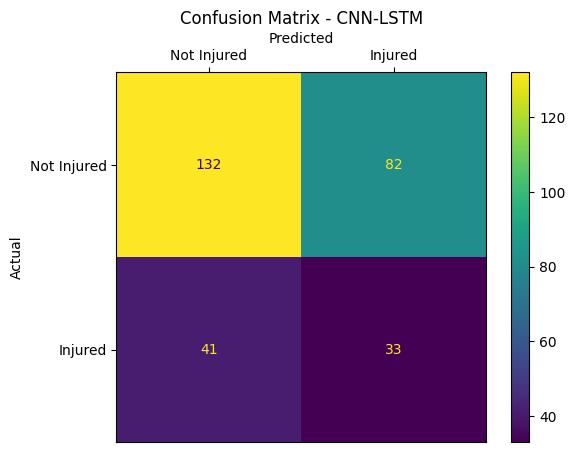

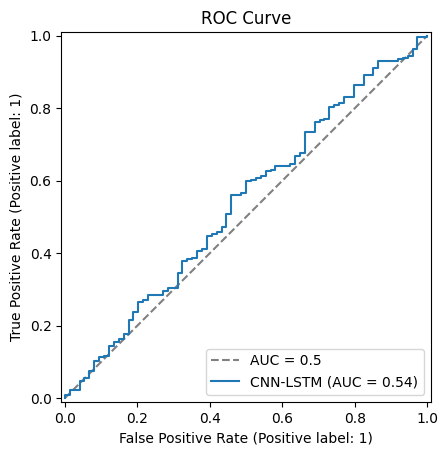

In [24]:
# Step 11: Evaluate on Test Set
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve, ConfusionMatrixDisplay, RocCurveDisplay

MODEL_NAME = "CNN-LSTM"

def plot_confusion_matrix(y_true, y_pred, labels):
    plt.figure()
    cm_disp = ConfusionMatrixDisplay.from_predictions(
        y_true, 
        y_pred, 
        display_labels=labels,
        labels=[1, 0]
    )
    cm_disp.ax_.xaxis.set_label_position('top')
    cm_disp.ax_.xaxis.set_ticks_position('top')
    cm_disp.ax_.xaxis.set_label_text('Predicted')
    cm_disp.ax_.yaxis.set_label_text('Actual')
    cm_disp.ax_.set_title(f'Confusion Matrix - {MODEL_NAME}')

def plot_roc_curve(y_true, y_pred_proba):
    plt.figure()
    ax = plt.gca()
    ax.plot([0, 1], [0, 1], linestyle='--', color='gray', label='AUC = 0.5')

    roc_disp = RocCurveDisplay.from_predictions(
        y_true, 
        y_pred_proba, 
        name=MODEL_NAME,
        ax=ax,
    )
    roc_disp.ax_.set_title('ROC Curve')

# Make predictions on test set
y_pred_proba = model.predict([X_ts_test, X_meta_test])
THRESHOLD = 0.5
y_pred = (y_pred_proba > THRESHOLD).astype(int).flatten()

# Calculate metrics
test_loss, test_accuracy, test_precision, test_recall = model.evaluate(
    [X_ts_test, X_meta_test], y_test, verbose=0
)

auc_score = roc_auc_score(y_test, y_pred_proba)

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")
print(f"Test Precision: {test_precision:.4f}")
print(f"Test Recall: {test_recall:.4f}")
print(f"Test AUC: {auc_score:.4f}")

# Detailed classification report
print(classification_report(y_test, y_pred, target_names=['Not Injured', 'Injured']))

# Confusion Matrix
plot_confusion_matrix(y_test, y_pred, labels=['Not Injured', 'Injured'])

# ROC Curve
plot_roc_curve(y_test, y_pred_proba)

# Calculate F1 Score
from sklearn.metrics import f1_score
f1 = f1_score(y_test, y_pred)
print(f"\nF1 Score: {f1:.4f}")

plt.show()


In [25]:
# Step 13: Save Model and Results
import pickle
import json

# Save the trained model
model.save(RESULTS_DIR / f'final_{MODEL_NAME}_model.h5')

# Save scalers for future use
with open(RESULTS_DIR / f'scalers_{MODEL_NAME}.pkl', 'wb') as f:
    pickle.dump({
        'timeseries_scaler': scaler_ts,
        'metadata_scaler': scaler_meta
    }, f)

# Save training results
results = {
    'test_accuracy': float(test_accuracy),
    'test_precision': float(test_precision),
    'test_recall': float(test_recall),
    'test_f1': float(f1),
    'test_auc': float(auc_score),
    'test_loss': float(test_loss),
    'model_architecture': 'CNN+LSTM+Dense hybrid',
    'features': {
        'timeseries_shape': list(X_ts_train.shape[1:]),
        'metadata_features': int(X_meta_train.shape[1]),
        'total_sessions': int(len(y)),
        'train_sessions': int(len(y_train_final)),
        'val_sessions': int(len(y_val)),
        'test_sessions': int(len(y_test))
    },
    'training_params': {
        'epochs_run': len(history.history['loss']),
        'batch_size': 32,
        'learning_rate': 0.001,
        'dropout_rate': 0.3,
        'class_weights': class_weight_dict
    }
}

with open(RESULTS_DIR / f'training_results_{MODEL_NAME}.json', 'w') as f:
    json.dump(results, f, indent=2)

print(f"=== MODEL SAVED ===")
print(f"Model saved to: {RESULTS_DIR / f'final_{MODEL_NAME}_model.h5'}")
print(f"Scalers saved to: {RESULTS_DIR / f'scalers_{MODEL_NAME}.pkl'}")
print(f"Results saved to: {RESULTS_DIR / f'training_results_{MODEL_NAME}.json'}")
print(f"\nFinal Test Results:")
print(f"- Accuracy: {test_accuracy:.3f}")
print(f"- Precision: {test_precision:.3f}")
print(f"- Recall: {test_recall:.3f}")
print(f"- F1-Score: {f1:.3f}")
print(f"- AUC: {auc_score:.3f}")


=== MODEL SAVED ===
Model saved to: /Users/adrianzapaterreig/Documents/Personal/TFM/data/Running Injury Clinic Kinematic Dataset/results/models/deep_learning/final_CNN-LSTM_model.h5
Scalers saved to: /Users/adrianzapaterreig/Documents/Personal/TFM/data/Running Injury Clinic Kinematic Dataset/results/models/deep_learning/scalers_CNN-LSTM.pkl
Results saved to: /Users/adrianzapaterreig/Documents/Personal/TFM/data/Running Injury Clinic Kinematic Dataset/results/models/deep_learning/training_results_CNN-LSTM.json

Final Test Results:
- Accuracy: 0.573
- Precision: 0.763
- Recall: 0.617
- F1-Score: 0.682
- AUC: 0.536


In [26]:
# Step 14: Model Explainability - Setup
print("=== EXPLAINABILITY ANALYSIS ===")

# Install required packages if needed (uncomment if running for first time)
# !pip install lime shap

import shap
import lime
import lime.lime_tabular
from lime.lime_text import LimeTextExplainer
import tensorflow as tf
from tensorflow.keras import backend as K
import numpy as np
import matplotlib.pyplot as plt

print("Explainability libraries imported successfully!")


=== EXPLAINABILITY ANALYSIS ===
Explainability libraries imported successfully!


In [27]:
# Step 15: Saliency Maps for Timeseries Data

def compute_timeseries_saliency(model, ts_input, meta_input, target_class=None):
    """
    Compute saliency maps for timeseries input using gradients.
    
    Args:
        model: Trained Keras model
        ts_input: Timeseries input array (1, 101, 48)
        meta_input: Metadata input array (1, n_features)
        target_class: Class to compute gradients for (0 or 1), if None uses predicted class
    
    Returns:
        saliency_map: Gradient-based saliency map for timeseries
    """
    
    # Convert to tensors
    ts_tensor = tf.Variable(ts_input, dtype=tf.float32)
    meta_tensor = tf.constant(meta_input, dtype=tf.float32)
    
    with tf.GradientTape() as tape:
        tape.watch(ts_tensor)
        predictions = model([ts_tensor, meta_tensor])
        
        if target_class is None:
            # Use predicted class
            target_class = tf.cast(predictions > 0.5, tf.int32)[0, 0]
        
        # Get the score for the target class
        if target_class == 1:
            score = predictions[0, 0]
        else:
            score = 1 - predictions[0, 0]
    
    # Compute gradients
    gradients = tape.gradient(score, ts_tensor)
    
    # Return saliency map (absolute gradients)
    return tf.abs(gradients).numpy()

def plot_timeseries_saliency(saliency_map, channels, sample_idx=0, top_k=10):
    """
    Plot saliency maps for timeseries data.
    
    Args:
        saliency_map: Saliency map array (1, 101, 48)
        channels: List of channel names
        sample_idx: Sample index to plot
        top_k: Number of top channels to highlight
    """
    
    saliency = saliency_map[sample_idx]  # Shape: (101, 48)
    
    # Calculate average importance per channel
    channel_importance = np.mean(saliency, axis=0)
    
    # Get top-k most important channels
    top_channels_idx = np.argsort(channel_importance)[-top_k:]
    
    fig, axes = plt.subplots(2, 1, figsize=(15, 10))
    
    # Plot 1: Heatmap of all channels
    im1 = axes[0].imshow(saliency.T, aspect='auto', cmap='hot', interpolation='nearest')
    axes[0].set_title('Saliency Map - All Channels')
    axes[0].set_xlabel('Time Steps (% of Stance Phase)')
    axes[0].set_ylabel('Channels')
    axes[0].set_yticks(range(0, len(channels), 5))
    axes[0].set_yticklabels([channels[i] for i in range(0, len(channels), 5)], fontsize=8)
    plt.colorbar(im1, ax=axes[0])
    
    # Plot 2: Top-k important channels over time
    for i, ch_idx in enumerate(top_channels_idx):
        axes[1].plot(saliency[:, ch_idx], label=channels[ch_idx], linewidth=2)
    
    axes[1].set_title(f'Top {top_k} Most Important Channels Over Time')
    axes[1].set_xlabel('Time Steps (% of Stance Phase)')
    axes[1].set_ylabel('Saliency Score')
    axes[1].legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    return top_channels_idx, channel_importance

# Example: Compute saliency for a few test samples
print("Computing saliency maps for test samples...")

# Select a few interesting test samples (one from each class)
injured_idx = np.where(y_test == 1)[0][0]  # First injured sample
healthy_idx = np.where(y_test == 0)[0][0]  # First healthy sample

print(f"Analyzing injured sample (index {injured_idx}) and healthy sample (index {healthy_idx})")


Computing saliency maps for test samples...
Analyzing injured sample (index 1) and healthy sample (index 0)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
Injured sample - Actual: True, Predicted: 1

=== SALIENCY MAP: INJURED SAMPLE ===


/var/folders/2w/vl1bz9zs2c37dzy7d38b9cbm0000gn/T/ipykernel_43906/1128242475.py:6: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  print(f"Injured sample - Actual: {y_test[injured_idx]}, Predicted: {(model.predict([injured_ts, injured_meta])[0,0] > 0.5).astype(int)}")


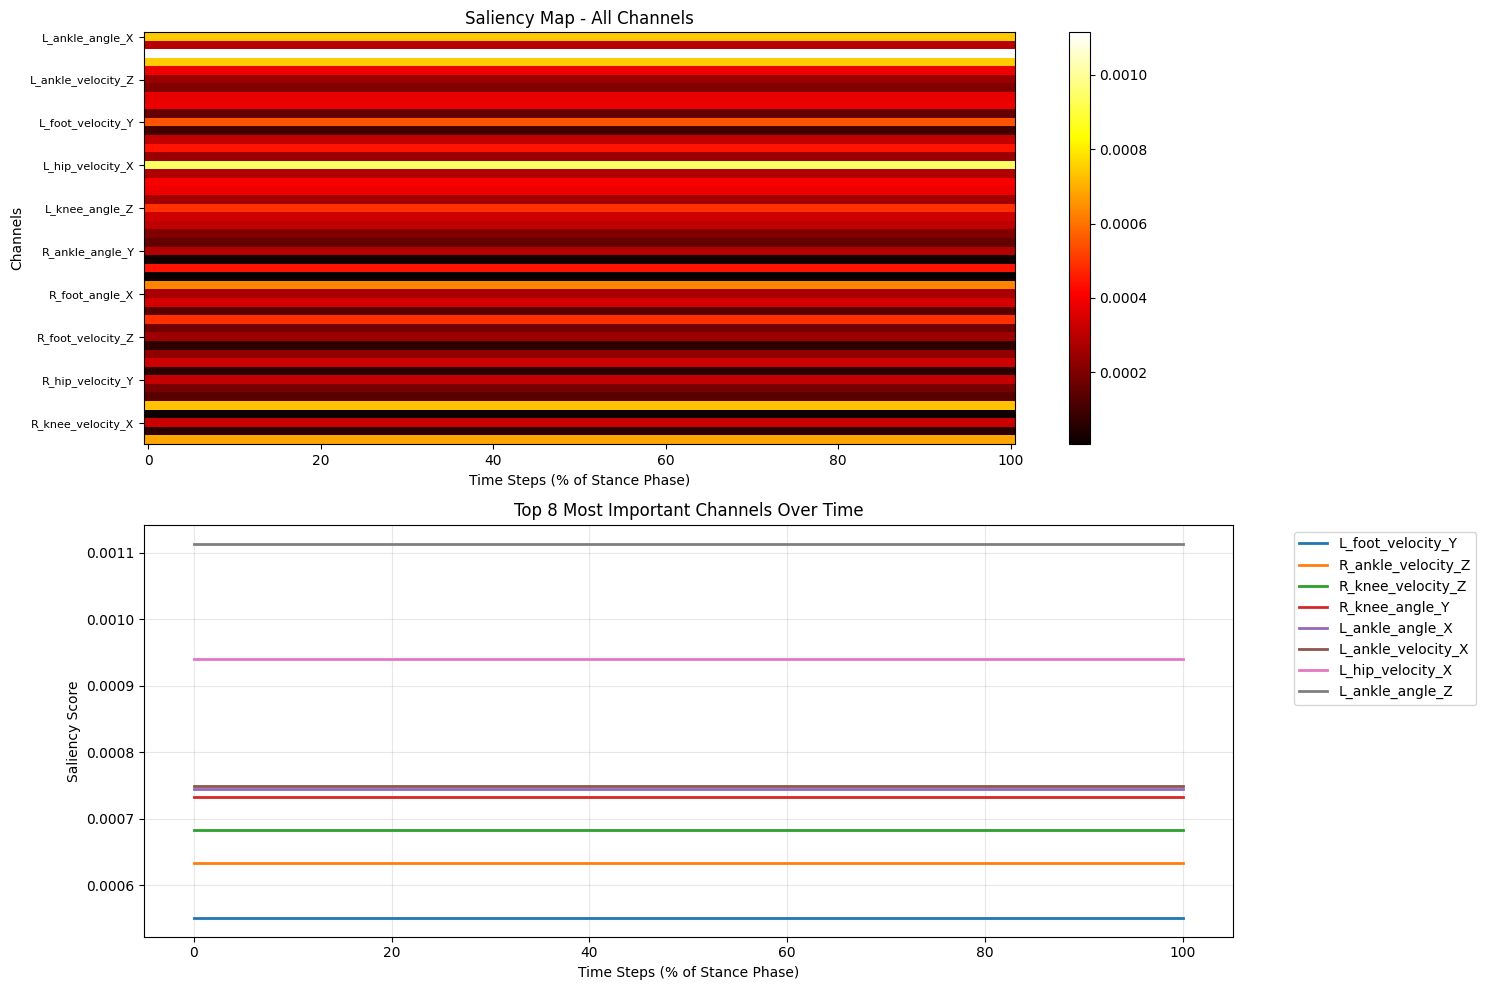

Injured sample saliency saved to: /Users/adrianzapaterreig/Documents/Personal/TFM/data/Running Injury Clinic Kinematic Dataset/results/models/deep_learning/saliency_injured_sample.png


<Figure size 640x480 with 0 Axes>

In [28]:
# Compute saliency maps for injured sample
injured_ts = X_ts_test[injured_idx:injured_idx+1]
injured_meta = X_meta_test[injured_idx:injured_idx+1]

saliency_injured = compute_timeseries_saliency(model, injured_ts, injured_meta, target_class=1)
print(f"Injured sample - Actual: {y_test[injured_idx]}, Predicted: {(model.predict([injured_ts, injured_meta])[0,0] > 0.5).astype(int)}")

print("\n=== SALIENCY MAP: INJURED SAMPLE ===")
top_channels_injured, importance_injured = plot_timeseries_saliency(saliency_injured, channels, top_k=8)

# Save the plot
plt.savefig(RESULTS_DIR / 'saliency_injured_sample.png', dpi=300, bbox_inches='tight')
print(f"Injured sample saliency saved to: {RESULTS_DIR / 'saliency_injured_sample.png'}")


/var/folders/2w/vl1bz9zs2c37dzy7d38b9cbm0000gn/T/ipykernel_43906/3356506134.py:6: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  print(f"Healthy sample - Actual: {y_test[healthy_idx]}, Predicted: {(model.predict([healthy_ts, healthy_meta])[0,0] > 0.5).astype(int)}")


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
Healthy sample - Actual: False, Predicted: 0

=== SALIENCY MAP: HEALTHY SAMPLE ===


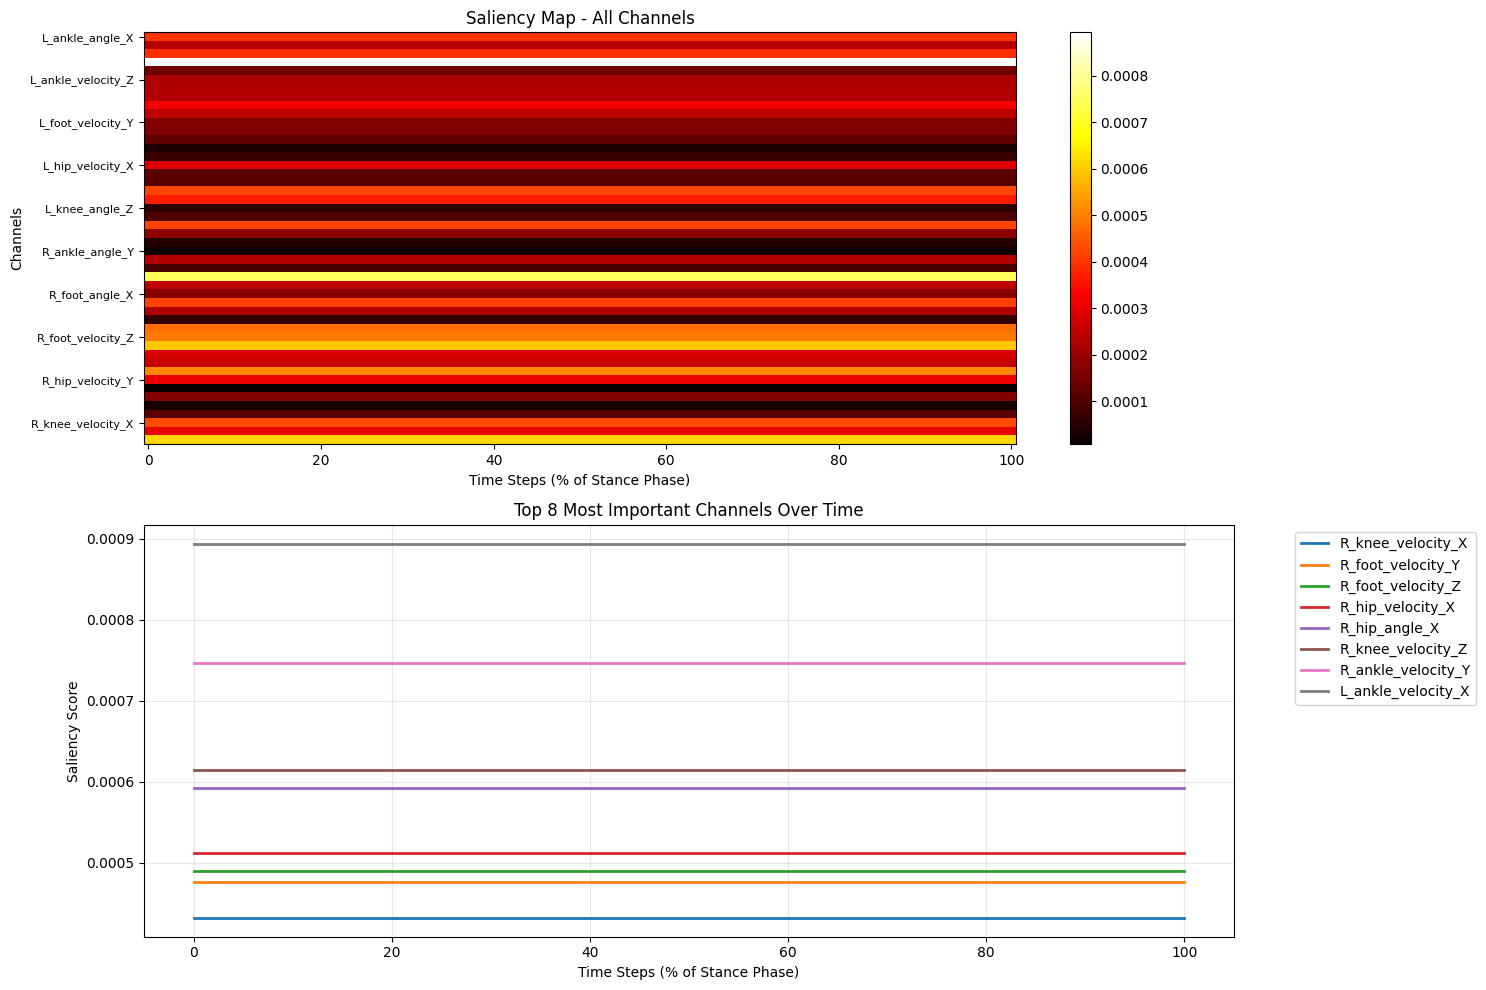

Healthy sample saliency saved to: /Users/adrianzapaterreig/Documents/Personal/TFM/data/Running Injury Clinic Kinematic Dataset/results/models/deep_learning/saliency_healthy_sample.png


<Figure size 640x480 with 0 Axes>

In [29]:
# Compute saliency maps for healthy sample
healthy_ts = X_ts_test[healthy_idx:healthy_idx+1]
healthy_meta = X_meta_test[healthy_idx:healthy_idx+1]

saliency_healthy = compute_timeseries_saliency(model, healthy_ts, healthy_meta, target_class=0)
print(f"Healthy sample - Actual: {y_test[healthy_idx]}, Predicted: {(model.predict([healthy_ts, healthy_meta])[0,0] > 0.5).astype(int)}")

print("\n=== SALIENCY MAP: HEALTHY SAMPLE ===")
top_channels_healthy, importance_healthy = plot_timeseries_saliency(saliency_healthy, channels, top_k=8)

# Save the plot
plt.savefig(RESULTS_DIR / 'saliency_healthy_sample.png', dpi=300, bbox_inches='tight')
print(f"Healthy sample saliency saved to: {RESULTS_DIR / 'saliency_healthy_sample.png'}")


Analyzing 50 samples for global importance...



=== GLOBAL FEATURE IMPORTANCE ===


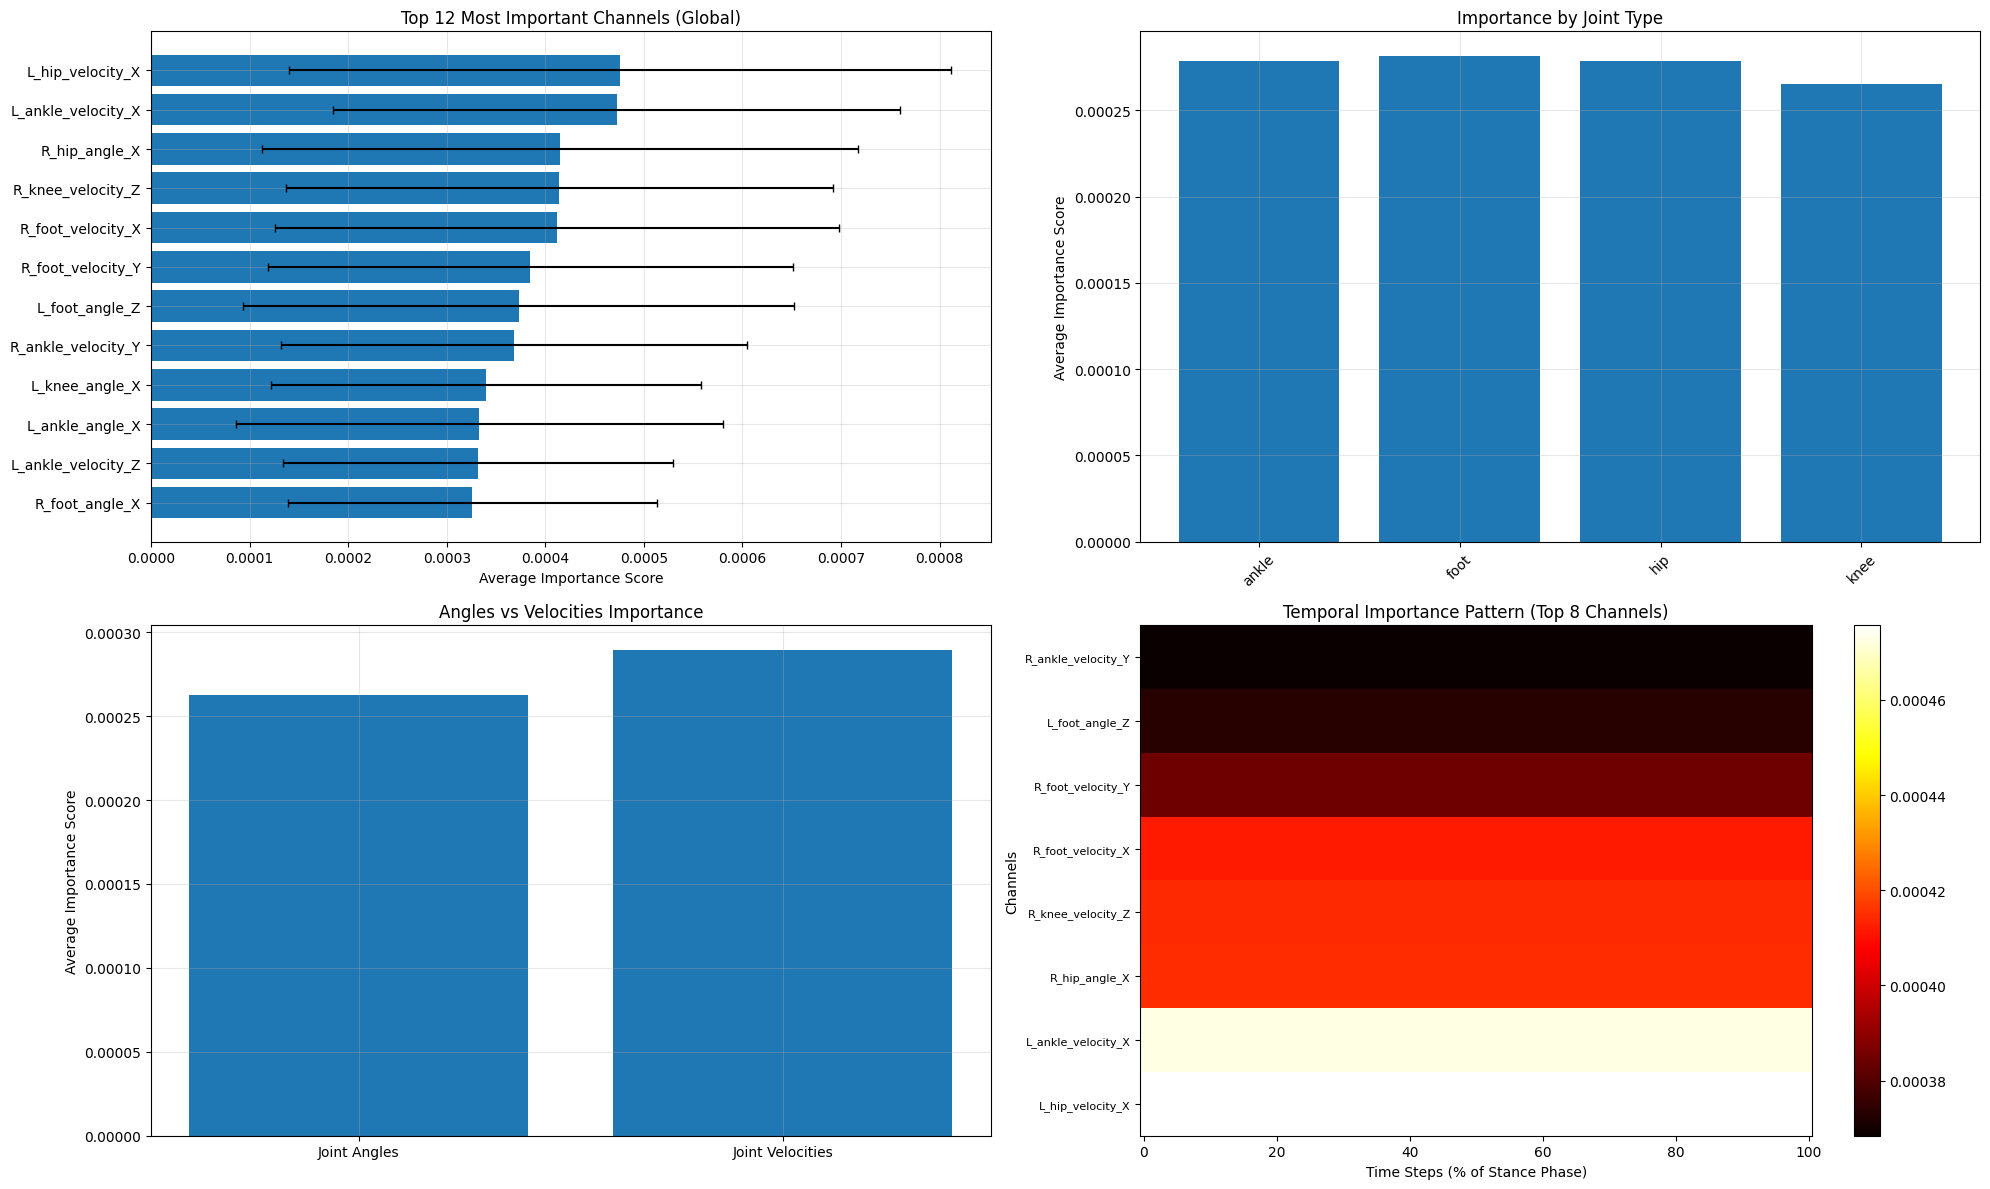

Global importance plot saved to: /Users/adrianzapaterreig/Documents/Personal/TFM/data/Running Injury Clinic Kinematic Dataset/results/models/deep_learning/global_feature_importance.png


<Figure size 640x480 with 0 Axes>

In [30]:
# Step 16: Global Feature Importance Analysis

def analyze_global_feature_importance(model, X_ts_sample, X_meta_sample, channels, n_samples=100):
    """
    Analyze global feature importance across multiple samples.
    
    Args:
        model: Trained model
        X_ts_sample: Sample of timeseries data
        X_meta_sample: Sample of metadata
        channels: Channel names
        n_samples: Number of samples to analyze
    
    Returns:
        Dictionary with importance statistics
    """
    
    n_samples = min(n_samples, len(X_ts_sample))
    all_saliencies = []
    
    print(f"Analyzing {n_samples} samples for global importance...")
    
    for i in range(n_samples):
        ts_input = X_ts_sample[i:i+1]
        meta_input = X_meta_sample[i:i+1]
        
        saliency = compute_timeseries_saliency(model, ts_input, meta_input)
        all_saliencies.append(saliency[0])  # Remove batch dimension
    
    all_saliencies = np.array(all_saliencies)  # Shape: (n_samples, 101, 48)
    
    # Calculate statistics
    mean_importance = np.mean(all_saliencies, axis=(0, 1))  # Average over samples and time
    std_importance = np.std(all_saliencies, axis=(0, 1))
    
    # Time-averaged importance for each channel
    temporal_importance = np.mean(all_saliencies, axis=0)  # Shape: (101, 48)
    
    return {
        'mean_importance': mean_importance,
        'std_importance': std_importance, 
        'temporal_importance': temporal_importance,
        'all_saliencies': all_saliencies,
        'channels': channels
    }

# Analyze global importance
global_importance = analyze_global_feature_importance(
    model, X_ts_test, X_meta_test, channels, n_samples=50
)

# Plot global feature importance
def plot_global_importance(importance_data, top_k=15):
    """Plot global feature importance analysis."""
    
    mean_imp = importance_data['mean_importance']
    std_imp = importance_data['std_importance']
    channels = importance_data['channels']
    temporal_imp = importance_data['temporal_importance']
    
    # Get top-k most important channels
    top_channels_idx = np.argsort(mean_imp)[-top_k:]
    
    fig, axes = plt.subplots(2, 2, figsize=(20, 12))
    
    # Plot 1: Top channel importance with error bars
    y_pos = np.arange(len(top_channels_idx))
    axes[0, 0].barh(y_pos, mean_imp[top_channels_idx], 
                    xerr=std_imp[top_channels_idx], capsize=3)
    axes[0, 0].set_yticks(y_pos)
    axes[0, 0].set_yticklabels([channels[i] for i in top_channels_idx])
    axes[0, 0].set_xlabel('Average Importance Score')
    axes[0, 0].set_title(f'Top {top_k} Most Important Channels (Global)')
    axes[0, 0].grid(True, alpha=0.3)
    
    # Plot 2: Importance by joint type
    joint_importance = {}
    for i, channel in enumerate(channels):
        joint = channel.split('_')[1]  # Extract joint name (ankle, knee, etc.)
        if joint not in joint_importance:
            joint_importance[joint] = []
        joint_importance[joint].append(mean_imp[i])
    
    joint_means = {joint: np.mean(scores) for joint, scores in joint_importance.items()}
    joint_names = list(joint_means.keys())
    joint_scores = list(joint_means.values())
    
    axes[0, 1].bar(joint_names, joint_scores)
    axes[0, 1].set_ylabel('Average Importance Score')
    axes[0, 1].set_title('Importance by Joint Type')
    axes[0, 1].tick_params(axis='x', rotation=45)
    axes[0, 1].grid(True, alpha=0.3)
    
    # Plot 3: Importance by measurement type (angle vs velocity)
    angle_indices = [i for i, ch in enumerate(channels) if 'angle' in ch]
    velocity_indices = [i for i, ch in enumerate(channels) if 'velocity' in ch]
    
    angle_importance = np.mean(mean_imp[angle_indices])
    velocity_importance = np.mean(mean_imp[velocity_indices])
    
    axes[1, 0].bar(['Joint Angles', 'Joint Velocities'], 
                   [angle_importance, velocity_importance])
    axes[1, 0].set_ylabel('Average Importance Score')
    axes[1, 0].set_title('Angles vs Velocities Importance')
    axes[1, 0].grid(True, alpha=0.3)
    
    # Plot 4: Temporal importance heatmap for top channels
    temporal_top = temporal_imp[:, top_channels_idx[-8:]]  # Top 8 channels
    im = axes[1, 1].imshow(temporal_top.T, aspect='auto', cmap='hot')
    axes[1, 1].set_title('Temporal Importance Pattern (Top 8 Channels)')
    axes[1, 1].set_xlabel('Time Steps (% of Stance Phase)')
    axes[1, 1].set_ylabel('Channels')
    axes[1, 1].set_yticks(range(8))
    axes[1, 1].set_yticklabels([channels[i] for i in top_channels_idx[-8:]], fontsize=8)
    plt.colorbar(im, ax=axes[1, 1])
    
    plt.tight_layout()
    plt.show()
    
    return joint_importance, top_channels_idx

print("\n=== GLOBAL FEATURE IMPORTANCE ===")
joint_importance, top_global_channels = plot_global_importance(global_importance, top_k=12)

# Save the plot
plt.savefig(RESULTS_DIR / 'global_feature_importance.png', dpi=300, bbox_inches='tight')
print(f"Global importance plot saved to: {RESULTS_DIR / 'global_feature_importance.png'}")


In [31]:
# Step 17: SHAP Analysis for Metadata Features

def analyze_metadata_with_shap(model, X_meta_train, X_meta_test, X_ts_test, feature_names):
    """
    Use SHAP to explain metadata feature importance.
    
    Args:
        model: Trained model
        X_meta_train: Training metadata for background
        X_meta_test: Test metadata
        X_ts_test: Test timeseries (needed for model prediction)
        feature_names: Names of metadata features
    
    Returns:
        SHAP explainer and values
    """
    
    # Create a wrapper function for SHAP that handles both inputs
    def model_predict_meta(meta_data):
        """Predict using metadata, with mean timeseries as background."""
        n_samples = meta_data.shape[0]
        
        # Use mean timeseries as background for all predictions
        mean_ts = np.mean(X_ts_test, axis=0, keepdims=True)
        ts_background = np.tile(mean_ts, (n_samples, 1, 1))
        
        predictions = model.predict([ts_background, meta_data], verbose=0)
        return predictions.flatten()
    
    # Create SHAP explainer
    print("Creating SHAP explainer for metadata features...")
    background_meta = X_meta_train[:100]  # Use sample for background
    explainer = shap.KernelExplainer(model_predict_meta, background_meta)
    
    # Calculate SHAP values for test samples
    print("Computing SHAP values (this may take a few minutes)...")
    n_explain = min(50, len(X_meta_test))  # Limit for computational efficiency
    shap_values = explainer.shap_values(X_meta_test[:n_explain])
    
    return explainer, shap_values, feature_names

# Use the feature names from the preprocessing step
print(f"Using metadata feature names: {meta_feature_names}")

# Run SHAP analysis
print("\n=== SHAP ANALYSIS FOR METADATA ===")
shap_explainer, shap_values, feature_names = analyze_metadata_with_shap(
    model, X_meta_train, X_meta_test, X_ts_test, meta_feature_names
)


Using metadata feature names: ['age', 'Height', 'Weight', 'speed_r', 'Gender_female', 'Gender_male', 'DominantLeg_ambidextrous', 'DominantLeg_left', 'DominantLeg_right']

=== SHAP ANALYSIS FOR METADATA ===
Creating SHAP explainer for metadata features...
Computing SHAP values (this may take a few minutes)...


  0%|          | 0/50 [00:00<?, ?it/s]

/Users/adrianzapaterreig/Documents/Personal/TFM/rickd-analysis/.venv/lib/python3.11/site-packages/shap/explainers/_kernel.py:706: RuntimeWarning: divide by zero encountered in matmul
  w = np.linalg.solve(X.T @ WX, WX.T @ y)
/Users/adrianzapaterreig/Documents/Personal/TFM/rickd-analysis/.venv/lib/python3.11/site-packages/shap/explainers/_kernel.py:706: RuntimeWarning: overflow encountered in matmul
  w = np.linalg.solve(X.T @ WX, WX.T @ y)
/Users/adrianzapaterreig/Documents/Personal/TFM/rickd-analysis/.venv/lib/python3.11/site-packages/shap/explainers/_kernel.py:706: RuntimeWarning: invalid value encountered in matmul
  w = np.linalg.solve(X.T @ WX, WX.T @ y)


Creating SHAP visualizations...


/var/folders/2w/vl1bz9zs2c37dzy7d38b9cbm0000gn/T/ipykernel_43906/2924493412.py:6: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_meta_test[:len(shap_values)], feature_names=feature_names, show=False)


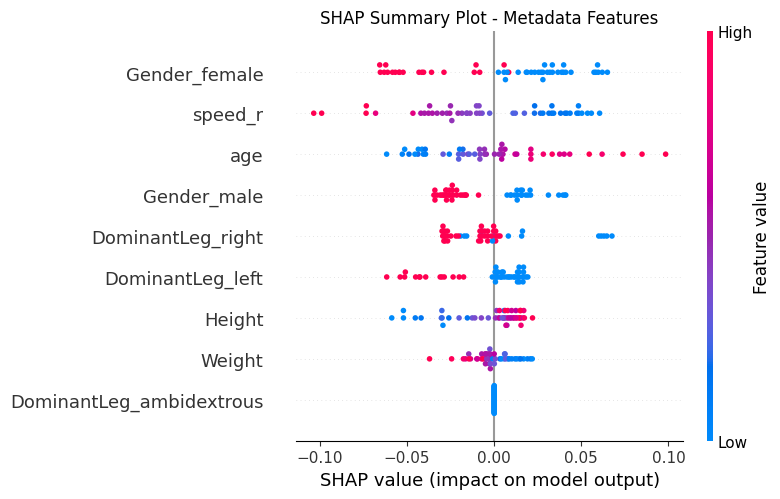

/var/folders/2w/vl1bz9zs2c37dzy7d38b9cbm0000gn/T/ipykernel_43906/2924493412.py:14: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_meta_test[:len(shap_values)], feature_names=feature_names, plot_type="bar", show=False)


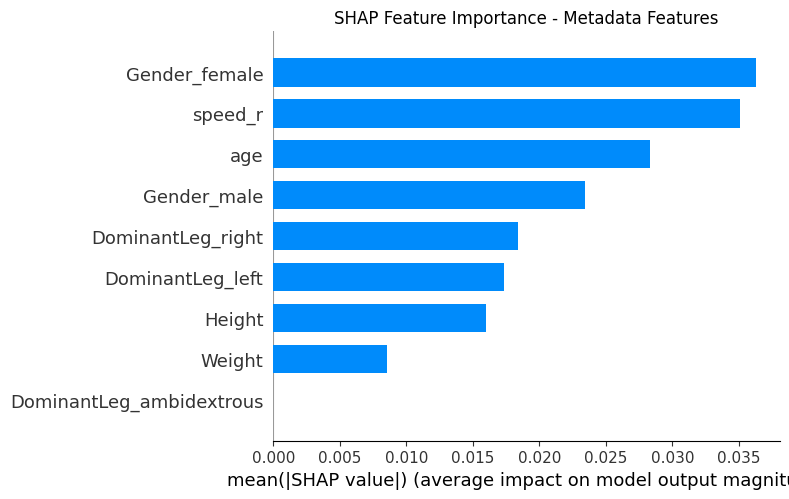

SHAP plots saved to: /Users/adrianzapaterreig/Documents/Personal/TFM/data/Running Injury Clinic Kinematic Dataset/results/models/deep_learning


In [32]:
# Plot SHAP results
print("Creating SHAP visualizations...")

# Summary plot
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_meta_test[:len(shap_values)], feature_names=feature_names, show=False)
plt.title('SHAP Summary Plot - Metadata Features')
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'shap_summary_metadata.png', dpi=300, bbox_inches='tight')
plt.show()

# Bar plot of feature importance
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_meta_test[:len(shap_values)], feature_names=feature_names, plot_type="bar", show=False)
plt.title('SHAP Feature Importance - Metadata Features')
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'shap_bar_metadata.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"SHAP plots saved to: {RESULTS_DIR}")



=== ACTIVATION MAXIMIZATION ===
Finding optimal pattern that maximizes injury prediction...
Iteration 0: Loss = -0.4944, Injury Prob = 0.5192
Iteration 200: Loss = -0.9840, Injury Prob = 0.9877
Iteration 400: Loss = -0.9897, Injury Prob = 0.9949
Iteration 600: Loss = -0.9907, Injury Prob = 0.9966
Iteration 800: Loss = -0.9911, Injury Prob = 0.9973


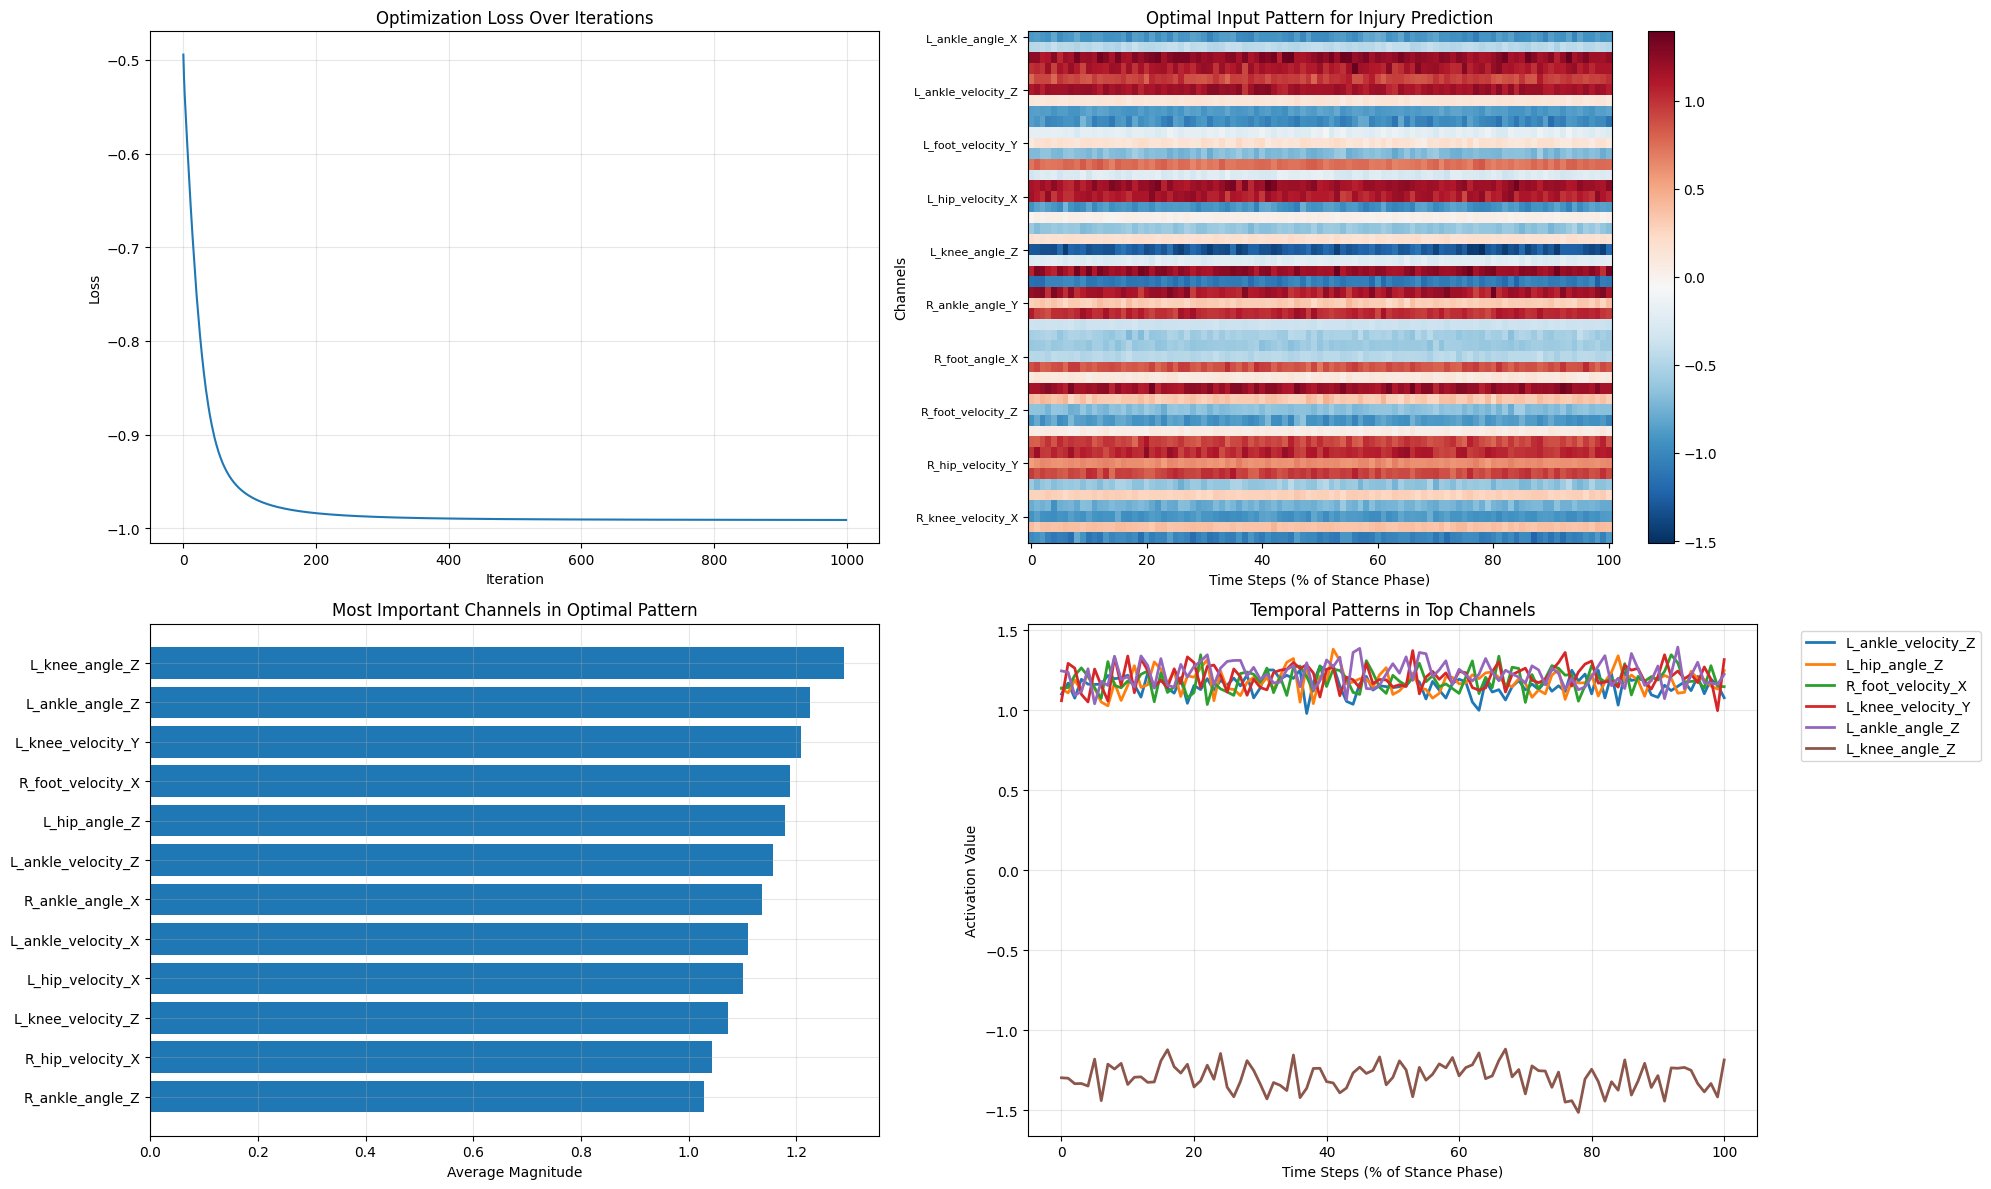

Activation maximization plot saved to: /Users/adrianzapaterreig/Documents/Personal/TFM/data/Running Injury Clinic Kinematic Dataset/results/models/deep_learning/activation_maximization.png

Final injury probability for optimal pattern: 0.9975


<Figure size 640x480 with 0 Axes>

In [36]:
# Step 19: Activation Maximization (What patterns activate injury prediction?)

def find_optimal_input_pattern(model, target_class=1, iterations=1000, learning_rate=0.01):
    """
    Find the input pattern that maximally activates the injury prediction.
    
    This helps understand what the model has learned as "injury patterns".
    
    Args:
        model: Trained model
        target_class: Class to optimize for (1 for injury)
        iterations: Number of optimization steps
        learning_rate: Learning rate for optimization
    
    Returns:
        Optimized timeseries pattern
    """
    
    # Initialize random input
    optimal_ts = tf.Variable(tf.random.normal((1, 101, 48), stddev=0.1), dtype=tf.float32)
    
    # Use mean metadata as fixed input
    mean_meta = tf.constant(np.mean(X_meta_test, axis=0, keepdims=True), dtype=tf.float32)
    
    optimizer = tf.keras.optimizers.Adam(learning_rate=learning_rate)
    
    losses = []
    
    for i in range(iterations):
        with tf.GradientTape() as tape:
            predictions = model([optimal_ts, mean_meta])
            
            if target_class == 1:
                # Maximize probability of injury
                loss = -predictions[0, 0]
            else:
                # Maximize probability of no injury
                loss = predictions[0, 0]
            
            # Add regularization to keep values reasonable
            regularization = 0.01 * tf.reduce_mean(tf.square(optimal_ts))
            loss += regularization
        
        gradients = tape.gradient(loss, optimal_ts)
        optimizer.apply_gradients([(gradients, optimal_ts)])
        
        losses.append(loss.numpy())
        
        if i % 200 == 0:
            prob = model.predict([optimal_ts, mean_meta], verbose=0)[0, 0]
            print(f"Iteration {i}: Loss = {loss:.4f}, Injury Prob = {prob:.4f}")
    
    return optimal_ts.numpy(), losses

print("\n=== ACTIVATION MAXIMIZATION ===")
print("Finding optimal pattern that maximizes injury prediction...")

optimal_injury_pattern, optimization_losses = find_optimal_input_pattern(
    model, target_class=1, iterations=1000
)

# Plot the results
fig, axes = plt.subplots(2, 2, figsize=(20, 12))

# Plot 1: Optimization loss
axes[0, 0].plot(optimization_losses)
axes[0, 0].set_title('Optimization Loss Over Iterations')
axes[0, 0].set_xlabel('Iteration')
axes[0, 0].set_ylabel('Loss')
axes[0, 0].grid(True, alpha=0.3)

# Plot 2: Optimal pattern heatmap
im1 = axes[0, 1].imshow(optimal_injury_pattern[0].T, aspect='auto', cmap='RdBu_r')
axes[0, 1].set_title('Optimal Input Pattern for Injury Prediction')
axes[0, 1].set_xlabel('Time Steps (% of Stance Phase)')
axes[0, 1].set_ylabel('Channels')
axes[0, 1].set_yticks(range(0, len(channels), 5))
axes[0, 1].set_yticklabels([channels[i] for i in range(0, len(channels), 5)], fontsize=8)
plt.colorbar(im1, ax=axes[0, 1])

# Plot 3: Channel importance in optimal pattern
channel_importance_optimal = np.mean(np.abs(optimal_injury_pattern[0]), axis=0)
top_optimal_channels = np.argsort(channel_importance_optimal)[-12:]

y_pos = np.arange(len(top_optimal_channels))
axes[1, 0].barh(y_pos, channel_importance_optimal[top_optimal_channels])
axes[1, 0].set_yticks(y_pos)
axes[1, 0].set_yticklabels([channels[i] for i in top_optimal_channels])
axes[1, 0].set_xlabel('Average Magnitude')
axes[1, 0].set_title('Most Important Channels in Optimal Pattern')
axes[1, 0].grid(True, alpha=0.3)

# Plot 4: Temporal patterns for top channels
for i, ch_idx in enumerate(top_optimal_channels[-6:]):
    axes[1, 1].plot(optimal_injury_pattern[0, :, ch_idx], 
                    label=channels[ch_idx], linewidth=2)

axes[1, 1].set_title('Temporal Patterns in Top Channels')
axes[1, 1].set_xlabel('Time Steps (% of Stance Phase)')
axes[1, 1].set_ylabel('Activation Value')
axes[1, 1].legend(bbox_to_anchor=(1.05, 1), loc='upper left')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Save the plot
plt.savefig(RESULTS_DIR / 'activation_maximization.png', dpi=300, bbox_inches='tight')
print(f"Activation maximization plot saved to: {RESULTS_DIR / 'activation_maximization.png'}")

# Final prediction for the optimal pattern
final_prob = model.predict([optimal_injury_pattern, np.mean(X_meta_test, axis=0, keepdims=True)], verbose=0)[0, 0]
print(f"\nFinal injury probability for optimal pattern: {final_prob:.4f}")
